# Simulating Bacteria

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/1-getting-started/DTGS172_bacteria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

In addition to simple geometric scatterers, DeepTrack also makes it possible to describe biological structures with more complex shapes. The examples below show how common bacterial morphologies can be represented as scatterers. These implementations are not intended as exact models of bacterial structure, but rather as demonstrations of how such scatterers can be created and adapted. You can use them directly, or take them as inspiration to design custom scatterers that fit your own application.

The examples are implemented in NumPy, though the same approach can be applied in PyTorch if preferred. If you would like to understand in more detail how scatterers are constructed in DeepTrack, you may first want to look at the [introductory tutorial on custom scatterers](./DTGS171A_custom_scatterers.ipynb).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import deeptrack as dt

# Depending on your installed version of Deeptrack, you might have to exchange
# the next line for "from deeptrack import units_registry as u"
from deeptrack import units as u
from deeptrack.backend.units import ConversionTable
from deeptrack.optical.scatterers import VolumeScatterer

## 1. Bacillus

Rod-shaped bacteria (bacilli) can be represented by combining a cylinder with hemispherical caps. The example `Bacillus` class below also includes the option to add bending along the length of the rod.

In [3]:
class Bacillus(VolumeScatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        length=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
    )

    def __init__(
            self,
            radius=0.5e-6,
            length=2e-6,
            rotation=(0, 0, 0),
            max_bacillus_bend=0,
            refractive_index=1.38,
            **kwargs
        ):
        super().__init__(
            radius=radius,
            length=length,
            rotation=rotation,
            max_bacillus_bend=max_bacillus_bend,
            refractive_index=refractive_index,
            **kwargs
        )

    def _process_properties(self, properties):
        properties = super()._process_properties(properties)

        # Ensure radius iis scalar
        radius = np.array(properties["radius"])
        if radius.size > 1:
            radius = radius[0]
        properties["radius"] = float(radius)

        # Ensure length is scalar
        properties["length"] = float(properties["length"])

        # Ensure rotation is 3 values
        rotation = np.array(properties["rotation"])
        if rotation.ndim == 0:
            rotation = [rotation, 0, 0]
        elif rotation.size == 1:
            rotation = [rotation[0], 0, 0]
        elif rotation.size == 2:
            rotation = [rotation[0], rotation[1], 0]
        properties["rotation"] = tuple(rotation)

        return properties

    def get(
        self,
        *ignore,
        radius,
        length,
        rotation,
        max_bacillus_bend,
        voxel_size,
        **kwargs
    ):

        # Determine grid size
        rad_ceil = np.ceil(radius / np.min(voxel_size[:2]))
        len_ceil = np.ceil(length * 0.5 / voxel_size[2]) + rad_ceil
        ceil = int(max(rad_ceil, len_ceil))

        # Create the grid
        x = np.arange(-ceil, ceil) * voxel_size[0]
        y = np.arange(-ceil, ceil) * voxel_size[1]
        z = np.arange(-ceil, ceil) * voxel_size[2]
        Y, X, Z = np.meshgrid(y, x, z)

        # Rotate the grid
        cos = np.cos(rotation)
        sin = np.sin(rotation)
        XR = (
            cos[0] * cos[1] * X
            + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
            + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
        )
        YR = (
            sin[0] * cos[1] * X
            + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
            + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
        )
        ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

        # Apply wave-like bending along the lenght of the bacillus
        bend_amp_x = (np.random.rand() - 0.5) * 2 * max_bacillus_bend
        bend_amp_z = (np.random.rand() - 0.5) * 2 * max_bacillus_bend
        lateral_offset_x = bend_amp_x * np.cos(np.pi * YR / length)
        lateral_offset_z = bend_amp_z * np.cos(np.pi * YR / length)
        XR -= lateral_offset_x
        ZR -= lateral_offset_z
        
        # Cylinder mask
        cyl_mask = ((XR**2 / radius ** 2 + ZR**2 / radius ** 2) < 1) & (
            np.abs(YR) < (length / 2)
        )
        # Hemispherical caps
        cap_mask = ((XR**2 + ZR**2 + (np.abs(YR) - (length/2))**2) < radius**2)

        # Combine the cylinder with the end-caps to form the full bacillus shape
        mask = cyl_mask | cap_mask

        return mask.astype(float)

In [4]:
bacillus = Bacillus(
    position=(64, 64),
)

optics = dt.Fluorescence()

pip = optics(bacillus)

c:\Users/xgrmir/Documents/DeepTrack2/DeepTrack2\deeptrack\optical\optics.py:1418: UserWarning: Scatterer defines 'refractive_index', which is ignored in fluorescence microscopy.
  warnings.warn(
c:\Users/xgrmir/Documents/DeepTrack2/DeepTrack2\deeptrack\optical\optics.py:1429: UserWarning: Fluorescence scatterer has no 'intensity'. Interpreting 'value' as a non-physical brightness factor. Quantitative interpretation is invalid. Define 'intensity' to model physical fluorescence emission.
  warnings.warn(


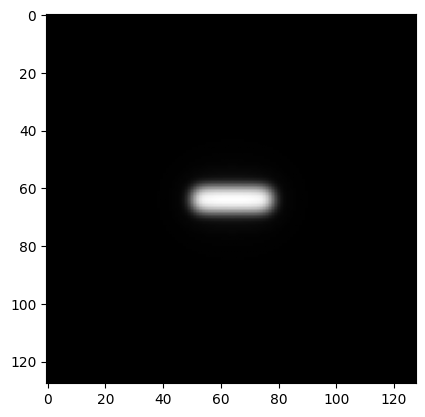

In [5]:
pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');

Once defined, bacilli can be placed at specific or random positions, given random orientations, and varied in size. Several instances can be combined into the same simulation, with tools such as `NonOverlapping` to avoid overlaps.

In [6]:
bacillus = Bacillus(
    position=lambda: np.random.uniform(0, 128, 2),
    rotation=lambda: np.random.uniform(0, 2*np.pi),
    length=lambda: np.random.uniform(1.6e-6, 2.6e-6),
    max_bacillus_bend=1e-7,
)

multiple_bacilli = (bacillus ^ (lambda: np.random.randint(5, 10)))

non_overlap_bac = dt.NonOverlapping(multiple_bacilli, min_distance=3)

pip = optics(non_overlap_bac)

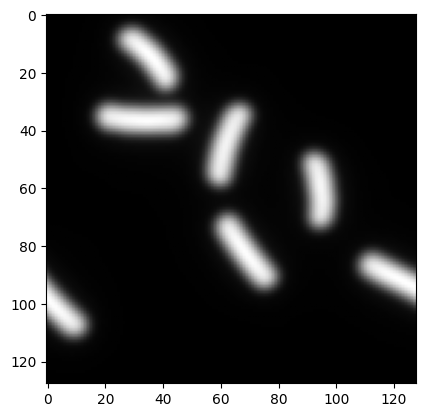

In [7]:
pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');

## 2. Streptobacillus
Streptobacilli are bacteria that form chains of bacilli. This can be modeled by arranging multiple bacilli end-to-end. The class below allows both the individual rods and the entire chain to bend slightly.

In [8]:
class Streptobacillus(VolumeScatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        length=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
    )

    def __init__(
            self,
            radius=0.5e-6,
            length=2e-6,
            n_bacilli=5,
            rotation=(0, 0, 0),
            max_chain_bend=0,
            max_bacillus_bend=0,
            refractive_index=1.38,
            **kwargs
        ):
        super().__init__(
            radius=radius,
            length=length,          # length of each part of the chain
            n_bacilli=n_bacilli,
            rotation=rotation,
            max_chain_bend=max_chain_bend,
            max_bacillus_bend=max_bacillus_bend,
            refractive_index=refractive_index,
            **kwargs
        )

    def _process_properties(self, properties):
        properties = super()._process_properties(properties)

        # Ensure radius iis scalar
        radius = np.array(properties["radius"])
        if radius.size > 1:
            radius = radius[0]
        properties["radius"] = float(radius)

        # # Ensure length is scalar
        # properties["length"] = float(properties["length"])

        # Ensure length is float or iterable of floats
        length = properties["length"]
        if np.ndim(length) == 0:
            properties["length"] = float(length)
        else:
            properties["length"] = np.array(length, dtype=float)

        # Ensure n_bacilli is int
        properties["n_bacilli"] = int(properties.get("n_bacilli"))

        # Ensure rotation is 3 values
        rotation = np.array(properties["rotation"])
        if rotation.ndim == 0:
            rotation = [rotation, 0, 0]
        elif rotation.size == 1:
            rotation = [rotation[0], 0, 0]
        elif rotation.size == 2:
            rotation = [rotation[0], rotation[1], 0]
        properties["rotation"] = tuple(rotation)

        return properties

    def get(
        self,
        *ignore,
        radius,
        length,
        n_bacilli,
        rotation,
        max_chain_bend,
        max_bacillus_bend,
        voxel_size,
        **kwargs
    ):
        # Determine grid size
        rad_ceil = np.ceil(radius / np.min(voxel_size[:2]))
        len_ceil = (
            np.ceil(length * 0.5 * n_bacilli / voxel_size[2])
            + rad_ceil * n_bacilli
        )
        ceil = int(max(rad_ceil, len_ceil))

        # Create grid
        x = np.arange(-ceil, ceil) * voxel_size[0]
        y = np.arange(-ceil, ceil) * voxel_size[1]
        z = np.arange(-ceil, ceil) * voxel_size[2]
        Y, X, Z = np.meshgrid(y, x, z)

        # Rotate the grid
        cos = np.cos(rotation)
        sin = np.sin(rotation)
        XR = (
            cos[0] * cos[1] * X
            + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
            + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
        )
        YR = (
            sin[0] * cos[1] * X
            + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
            + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
        )
        ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

        shift = length + 2 * radius
        total_length = n_bacilli * (length + 2 * radius)

        mask = np.zeros_like(XR, dtype=bool)

        for i in range(n_bacilli):
            # Chain-level bending offsets
            bend_chain_x = (np.random.rand() - 0.5) * 2 * max_chain_bend
            bend_chain_z = (np.random.rand() - 0.5) * 2 * max_chain_bend

            # Shift chain along Y and apply chain bending
            YR_shifted = YR - i*shift + total_length/2 - shift/2
            XR_shifted = XR - bend_chain_x
            ZR_shifted = ZR - bend_chain_z

            # Wave-like bending along the lenght of the bacillus
            bend_amp_x = (np.random.rand() - 0.5) * 2 * max_bacillus_bend
            bend_amp_z = (np.random.rand() - 0.5) * 2 * max_bacillus_bend
            lateral_offset_x = bend_amp_x * np.cos(np.pi * YR_shifted / length)
            lateral_offset_z = bend_amp_z * np.cos(np.pi * YR_shifted / length)
            XR_shifted -= lateral_offset_x
            ZR_shifted -= lateral_offset_z

            # Cylinder mask
            cyl_mask = (
                (XR_shifted**2 / radius**2 + ZR_shifted**2 / radius**2) < 1
            ) & (np.abs(YR_shifted) < length / 2)

            # Hemispherical caps
            cap_mask = (
                XR_shifted**2
                + ZR_shifted**2
                + (np.abs(YR_shifted) - length / 2) ** 2
            ) < radius**2

            # Combine the cylinder with the end-caps
            mask |= (cyl_mask | cap_mask)

        return mask.astype(float)

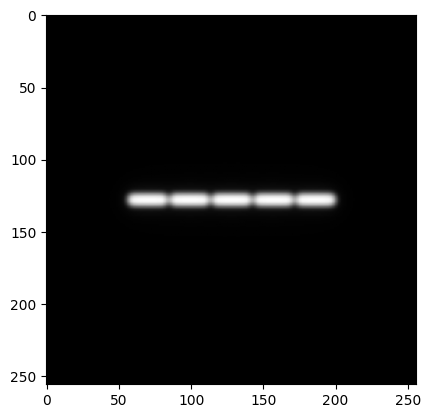

In [9]:
strepto = Streptobacillus(
    position=(128, 128)
)

optics = dt.Fluorescence(
    output_region=(0, 0, 256, 256)
)

pip = optics(strepto)

pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');

By adjusting the number of bacilli, their length, and the bending parameters, it is possible to create different chain morphologies. This is one way to mimic the diversity that may appear in experiments.

In [10]:
strepto = Streptobacillus(
    position=lambda: np.random.uniform(50, 206, 2),
    n_bacilli=lambda: np.random.randint(3, 6),
    max_chain_bend=0.15e-6,
    max_bacillus_bend=0.15e-6,
    rotation=lambda: np.random.uniform(0, 2*np.pi),
)

optics = dt.Fluorescence(
    output_region=(0, 0, 256, 256)
)

pip = optics(strepto ^ 2)

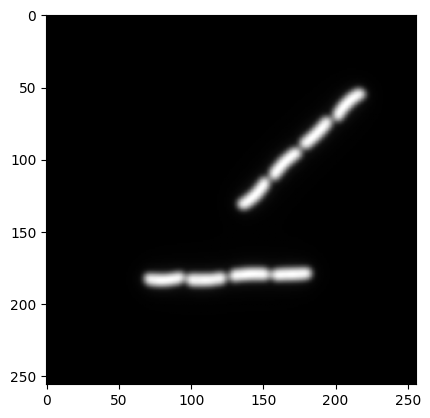

In [11]:
pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');

## 3. Streptococcus:
Streptococci are spherical bacteria that typically grow in chains. A simple way to describe them is as a series of spheres arranged along an axis. The example `Streptococcus` class implements this approach, and also allows the chain to bend smoothly.

In [12]:
class Streptococcus(VolumeScatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        length=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
    )

    def __init__(
            self,
            radius=0.5e-6,
            n_coccus=5,
            rotation=(0, 0, 0),
            max_chain_bend=0,
            refractive_index=1.38,
            **kwargs
        ):
        super().__init__(
            radius=radius,
            n_coccus=n_coccus,
            rotation=rotation,
            max_chain_bend=max_chain_bend,
            refractive_index=refractive_index,
            **kwargs
        )

    def _process_properties(self, properties):
        properties = super()._process_properties(properties)

        # Ensure radius iis scalar
        radius = np.array(properties["radius"])
        if radius.size > 1:
            radius = radius[0]
        properties["radius"] = float(radius)

        # Ensure n_bacilli is int
        properties["n_coccus"] = int(properties.get("n_coccus"))

        # Ensure rotation is 3 values
        rotation = np.array(properties["rotation"])
        if rotation.ndim == 0:
            rotation = [rotation, 0, 0]
        elif rotation.size == 1:
            rotation = [rotation[0], 0, 0]
        elif rotation.size == 2:
            rotation = [rotation[0], rotation[1], 0]
        properties["rotation"] = tuple(rotation)

        return properties

    def get(
        self,
        *ignore,
        radius,
        n_coccus,
        rotation,
        max_chain_bend,
        voxel_size,
        **kwargs
    ):
        # Determine grid size
        rad_ceil = np.ceil(radius / np.min(voxel_size[:2]))
        len_ceil = rad_ceil * n_coccus
        ceil = len_ceil

        # Create grid
        x = np.arange(-ceil, ceil) * voxel_size[0]
        y = np.arange(-ceil, ceil) * voxel_size[1]
        z = np.arange(-ceil, ceil) * voxel_size[2]
        Y, X, Z = np.meshgrid(y, x, z)

        # Rotate the grid
        cos = np.cos(rotation)
        sin = np.sin(rotation)
        XR = (
            cos[0] * cos[1] * X
            + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
            + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
        )
        YR = (
            sin[0] * cos[1] * X
            + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
            + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
        )
        ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

        shift = 2 * radius
        total_length = n_coccus * 2 * radius

        mask = np.zeros_like(XR, dtype=bool)

        # Generate smooth random offsets along the chain
        bend_x_offsets = (np.random.rand(n_coccus) - 0.5) * 2 * max_chain_bend
        bend_z_offsets = (np.random.rand(n_coccus) - 0.5) * 2 * max_chain_bend
        
        # Smooth offsets for more natural curve
        for i in range(1, n_coccus):
            bend_x_offsets[i] = (
                0.7 * bend_x_offsets[i - 1] + 0.3 * bend_x_offsets[i]
            )
            bend_z_offsets[i] = (
                0.7 * bend_z_offsets[i - 1] + 0.3 * bend_z_offsets[i]
            )

        shift = 2 * radius
        total_length = n_coccus * shift

        for i in range(n_coccus):
            # Shift along Y and add realistic random bend
            YR_shifted = YR - i * shift + total_length / 2 - shift / 2
            XR_shifted = XR - bend_x_offsets[i]
            ZR_shifted = ZR - bend_z_offsets[i]

            coccus_mask = (
                XR_shifted**2 + YR_shifted**2 + ZR_shifted**2
            ) < radius**2
            mask |= coccus_mask

        return mask.astype(float)

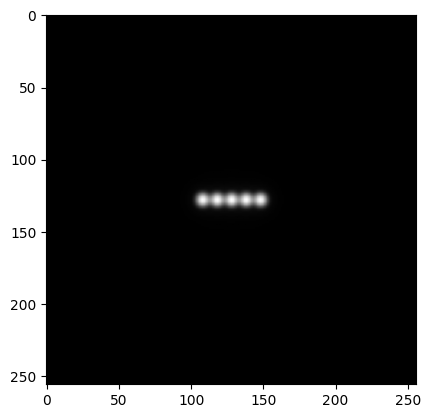

In [13]:
strepto = Streptococcus(
    position=(128, 128)
)

optics = dt.Fluorescence(
    output_region=(0, 0, 256, 256)
)

pip = optics(strepto)

pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');

Parameters such as the number of spheres, their radius, and the amount of bending can be adjusted. As with the other examples, several chains can be placed in the same image.

In [14]:
strepto = Streptococcus(
    position=lambda: np.random.uniform(50, 206, 2),
    n_coccus=lambda: np.random.randint(5, 12),
    max_chain_bend=1.5e-6,
    rotation=lambda: np.random.uniform(0, 2*np.pi),
)

optics = dt.Fluorescence(
    output_region=(0, 0, 256, 256)
)

pip = optics(strepto ^ 3)

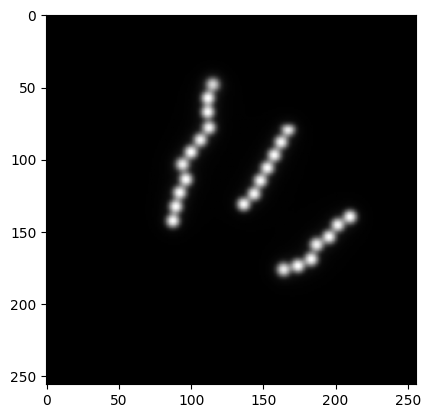

In [15]:
pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');